# StaySure ML — Milestone 1: Data Audit

**Business problem:** Predict whether a hotel reservation will be canceled.

**Prediction point:** Immediately after the reservation is confirmed. Only information available at that moment may be used as a model feature.

**Your role:** You are the analyst. Complete each `TODO`, explain what the result means, and record your decisions.

## Learning objectives

By the end of this notebook, you will be able to:

1. Load and verify a large CSV dataset.
2. Inspect shape, columns, data types, and memory use.
3. Measure missing values and duplicate rows.
4. Examine the cancellation target and class balance.
5. identify suspicious or impossible values.
6. recognize target leakage.
7. document data-cleaning decisions for the next milestone.

### How to work

- Run cells from top to bottom.
- Attempt every `TODO` before opening its solution.
- Add your own explanation beneath each interpretation prompt.
- A wrong result is useful evidence. Recheck the data and revise your code.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid")

print("Imports loaded successfully.")

Imports loaded successfully.


## 1. Locate and load the dataset

This notebook expects the following project structure:

```text
staysure-hotel-cancellation-ml/
├── data/
│   └── raw/
│       └── hotel_bookings.csv
└── notebooks/
    └── 01_data_audit.ipynb
```

In [2]:
candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (root for root in candidate_roots if (root / "data" / "raw" / "hotel_bookings.csv").exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find data/raw/hotel_bookings.csv. "
        "Place this notebook in the notebooks folder and open the project folder in VS Code."
    )

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "hotel_bookings.csv"
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)

Project root: c:\Users\theko\ML_Projects\staysure-hotel-cancellation-ml
Dataset path: c:\Users\theko\ML_Projects\staysure-hotel-cancellation-ml\data\raw\hotel_bookings.csv


In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print("Dataset loaded.")
display(df.head())

Dataset loaded.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03


### Checkpoint helper

The helper tells you whether a short answer is correct without displaying the expected answer.

In [4]:
def check_value(label, answer, expected):
    if answer is None:
        print(f"{label}: not completed yet.")
    elif answer == expected:
        print(f"{label}: correct.")
    else:
        print(f"{label}: not yet. Recheck your calculation.")

## 2. Confirm dataset size

**TODO 1:** Use `df.shape` to assign the number of rows and columns. This verifies that the full dataset loaded.

In [9]:
# TODO 1: Replace None with values obtained from df.shape.
row_count, column_count = df.shape 

check_value("Row count", row_count, 119_390)
check_value("Column count", column_count, 32)

Row count: correct.
Column count: correct.


<details>
<summary>Open the TODO 1 solution after attempting it</summary>

```python
row_count, column_count = df.shape
```

The underscore in `119_390` only makes the number easier to read. Python treats it as `119390`.
</details>

In [10]:
# Completed example: estimate the DataFrame's memory use.
memory_mb = df.memory_usage(deep=True).sum() / 1_000_000
print(f"Approximate DataFrame memory: {memory_mb:,.1f} MB")

Approximate DataFrame memory: 109.9 MB


## 3. Inspect columns and data types

Data types influence cleaning and modeling. Text categories usually need encoding. Numeric identifiers may need to be treated as categories rather than quantities. Dates require deliberate handling.

In [7]:
schema_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "unique_count": df.nunique(dropna=False),
})
display(schema_summary)

,dtype,non_null_count,unique_count
hotel,str,119390,2
is_canceled,int64,119390,2
lead_time,int64,119390,479
arrival_date_year,int64,119390,3
arrival_date_month,str,119390,12
arrival_date_week_number,int64,119390,53
arrival_date_day_of_month,int64,119390,31
stays_in_weekend_nights,int64,119390,17
stays_in_week_nights,int64,119390,35
adults,int64,119390,14


**TODO 2:** Create lists of categorical and numeric columns.

Hint: `df.select_dtypes(include=...)` returns the columns matching the requested types.

In [11]:
# TODO 2: Replace None with the correct expressions.
categorical_columns = df.select_dtypes(include="object").columns.tolist()
numeric_columns =df.select_dtypes(include=np.number).columns.tolist()

if categorical_columns is None or numeric_columns is None:
    print("TODO 2 is not completed yet.")
else:
    print(f"Categorical columns: {len(categorical_columns)}")
    print(f"Numeric columns: {len(numeric_columns)}")
    print("Categorical:", categorical_columns)

Categorical columns: 12
Numeric columns: 20
Categorical: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\theko\AppData\Local\Temp\ipykernel_23776\4024285996.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


<details>
<summary>Open the TODO 2 solution after attempting it</summary>

```python
categorical_columns = df.select_dtypes(include="object").columns.tolist()
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
```

A numeric dtype does not automatically make a field continuous. For example, `agent` and `company` behave like identifiers.
</details>

### Key fields for this project

| Field | Meaning | Initial role |
|---|---|---|
| `is_canceled` | 1 if the booking was canceled, otherwise 0 | Target |
| `lead_time` | Days between booking and arrival | Candidate feature |
| `adr` | Average daily rate | Candidate feature |
| `hotel` | Resort Hotel or City Hotel | Candidate feature |
| `reservation_status` | Final booking outcome | Leakage; remove |
| `reservation_status_date` | Date of final status | Leakage; remove |
| `agent`, `company` | Booking-related identifiers | Review as categorical/ID fields |

## 4. Audit missing values

Start with counts. Then calculate percentages so columns with different scales can be compared.

In [12]:
# Completed example: missing counts only.
missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0].to_frame("missing_count"))

,missing_count
company,112593
agent,16340
country,488
children,4


In [13]:
# TODO 3: Build a table with missing_count and missing_percent.
# Keep only columns containing at least one missing value and sort largest first.
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100),
})
missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percent", ascending=False)
)

if missing_summary is None:
    print("TODO 3 is not completed yet.")
else:
    display(missing_summary)

,missing_count,missing_percent
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


<details>
<summary>Open the TODO 3 solution after attempting it</summary>

```python
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100),
})
missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percent", ascending=False)
)
display(missing_summary)
```
</details>

**Interpretation prompt:** Which missing values probably mean “not applicable,” and which may indicate unknown information? Why should `agent` and `company` not automatically be filled with their numerical mean?

## 5. Check duplicate rows

Duplicate rows can inflate performance if identical records appear in both training and test sets. However, identical booking attributes do not necessarily prove that the records are accidental duplicates because this dataset has no unique booking ID. Audit first; decide later.

In [14]:
# TODO 4: Count exact duplicate rows.
duplicate_count = df.duplicated().sum()
duplicate_percent = duplicate_count / len(df) * 100

check_value("Exact duplicate count", duplicate_count, 31_994)
if duplicate_percent is not None:
    print(f"Rows marked as exact duplicates: {duplicate_percent:.2f}%")

Exact duplicate count: correct.
Rows marked as exact duplicates: 26.80%


<details>
<summary>Open the TODO 4 solution after attempting it</summary>

```python
duplicate_count = df.duplicated().sum()
duplicate_percent = duplicate_count / len(df) * 100
```
</details>

**Decision prompt:** For this milestone, record the duplicates but do not delete them yet. In the cleaning milestone, compare model-validation risk with the possibility that identical rows represent different customers.

## 6. Audit the target variable

The target is `is_canceled`:

- `0` = not canceled
- `1` = canceled

A model that always predicts the majority class becomes the simplest baseline. Your later models should provide useful improvement beyond that baseline.

In [15]:
target_counts = df["is_canceled"].value_counts().sort_index()
# TODO 5: Calculate percentages by adding normalize=True to value_counts.
target_percent = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(target_counts.rename("count").to_frame())
if target_percent is None:
    print("TODO 5 is not completed yet.")
else:
    display(target_percent.rename("percent").to_frame())

,count
is_canceled,
0,75166
1,44224


,percent
is_canceled,
0,62.96
1,37.04


<details>
<summary>Open the TODO 5 solution after attempting it</summary>

```python
target_percent = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
```
</details>

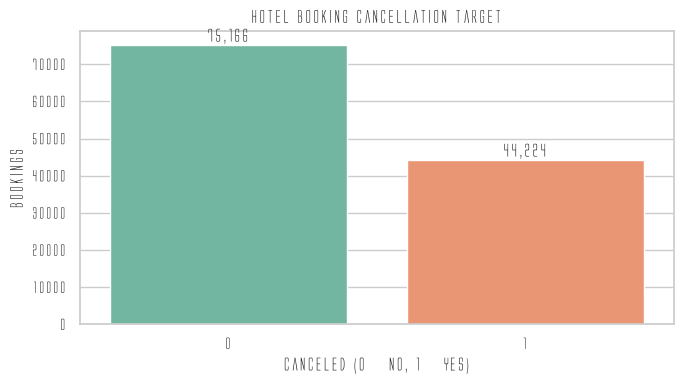

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="is_canceled", hue="is_canceled", legend=False, palette="Set2", ax=ax)
ax.set(title="Hotel booking cancellation target", xlabel="Canceled (0 = No, 1 = Yes)", ylabel="Bookings")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")
plt.tight_layout()
plt.show()

### Your interpretation

Write 2–4 sentences in a new Markdown cell answering these questions:

1. What percentage of reservations were canceled?
2. Is the target perfectly balanced, moderately imbalanced, or severely imbalanced?
3. Why will accuracy alone be insufficient when evaluating the model?
4. Which metrics should accompany accuracy? Consider precision, recall, F1, ROC-AUC, and the confusion matrix.

Approximately 37.04% of the reservations were canceled, while 62.96% were not canceled. The target is moderately imbalanced because non-canceled bookings are more common, but canceled bookings still represent a substantial portion of the dataset. Accuracy alone is insufficient because a model could favor the majority class and still fail to identify many cancellations. I will evaluate the model using precision, recall, F1-score, ROC-AUC, and the confusion matrix, with particular attention to recall for detecting canceled bookings and precision for limiting false cancellation warnings.

## 7. Check suspicious values

An audit does not silently delete unusual rows. It measures them, records possible explanations, and carries explicit decisions into the cleaning milestone.

In [18]:
# One completed example plus three TODO checks.
quality_checks = {
    "negative_adr": int(
        (df["adr"] < 0).sum()
    ),
    
    "zero_total_guests": int(
        (
            (
                df["adults"] 
                + df["children"].fillna(0) 
                + df["babies"] 
            )== 0)
        .sum()
    ),
    
    "zero_total_nights": int(
        (
            (
                df["stays_in_weekend_nights"] 
                + df["stays_in_week_nights"]
            ) == 0)
        .sum(0)
    ),
    
    "missing_children": int(
        df["children"].isna().sum()
    ),
    # TODO 6A: rows with adults + children + babies equal to zero
    # "zero_total_guests": ...,
    # TODO 6B: rows with weekend nights + week nights equal to zero
    # "zero_total_nights": ...,
    # TODO 6C: rows where children is missing
    # "missing_children": ...,
}

display(pd.Series(quality_checks, name="row_count").to_frame())

C:\Users\theko\AppData\Local\Temp\ipykernel_23776\2717234031.py:23: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  .sum(0)


,row_count
negative_adr,1
zero_total_guests,180
zero_total_nights,715
missing_children,4


<details>
<summary>Open the TODO 6 solution after attempting it</summary>

```python
quality_checks = {
    "negative_adr": int((df["adr"] < 0).sum()),
    "zero_total_guests": int(
        ((df["adults"] + df["children"].fillna(0) + df["babies"]) == 0).sum()
    ),
    "zero_total_nights": int(
        ((df["stays_in_weekend_nights"] + df["stays_in_week_nights"]) == 0).sum()
    ),
    "missing_children": int(df["children"].isna().sum()),
}
```
</details>

**Interpretation prompt:** Which conditions are impossible, which might represent same-day stays or administrative records, and which need confirmation before removal?

In [19]:
important_numeric = [
    "lead_time", "adr", "adults", "children", "babies",
    "stays_in_weekend_nights", "stays_in_week_nights",
]
display(df[important_numeric].describe().T)

,count,mean,std,min,25%,50%,75%,max
lead_time,"119,390.00",104.01,106.86,0.00,18.00,69.00,160.00,737.00
adr,"119,390.00",101.83,50.54,-6.38,69.29,94.58,126.00,"5,400.00"
adults,"119,390.00",1.86,0.58,0.00,2.00,2.00,2.00,55.00
children,"119,386.00",0.10,0.40,0.00,0.00,0.00,0.00,10.00
babies,"119,390.00",0.01,0.10,0.00,0.00,0.00,0.00,10.00
stays_in_weekend_nights,"119,390.00",0.93,1.00,0.00,0.00,1.00,2.00,19.00
stays_in_week_nights,"119,390.00",2.50,1.91,0.00,1.00,2.00,3.00,50.00


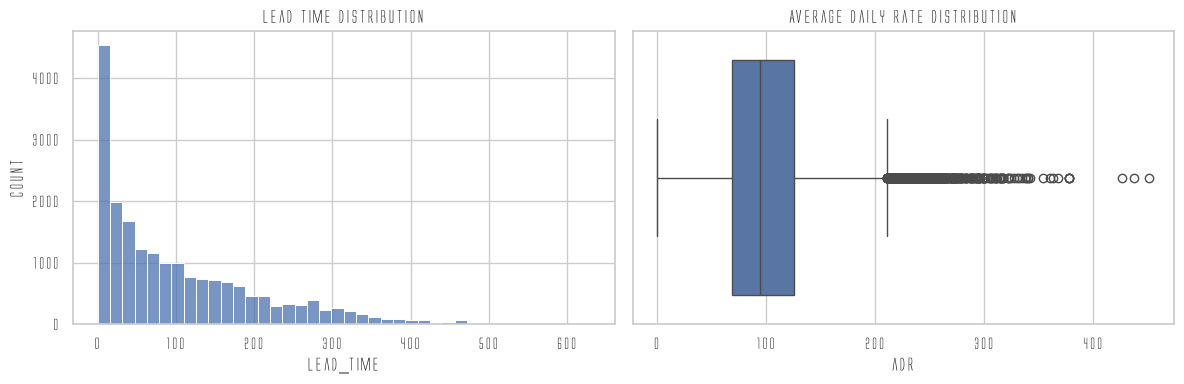

In [20]:
# Plot a sample for responsive rendering while preserving the full data for calculations.
plot_sample = df.sample(n=min(20_000, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=plot_sample, x="lead_time", bins=40, ax=axes[0])
axes[0].set_title("Lead time distribution")
sns.boxplot(data=plot_sample, x="adr", ax=axes[1])
axes[1].set_title("Average daily rate distribution")
plt.tight_layout()
plt.show()

## 8. Inspect categorical cardinality

Cardinality is the number of unique values. High-cardinality fields such as country or IDs can create many one-hot encoded columns.

In [21]:
object_columns = df.select_dtypes(include="object").columns
cardinality = df[object_columns].nunique(dropna=False).sort_values(ascending=False)
display(cardinality.rename("unique_values").to_frame())

cancellation_rate_by_hotel = (
    df.groupby("hotel")["is_canceled"]
    .mean()
    .mul(100)
    .round(2)
)

display(
    cancellation_rate_by_hotel
    .rename("cancellation_rate_percent")
    .to_frame()
)
# TODO 7: Explore cancellation rate by hotel type.
# Hint: df.groupby("hotel")["is_canceled"].mean()

C:\Users\theko\AppData\Local\Temp\ipykernel_23776\3308644525.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns


,unique_values
reservation_status_date,926
country,178
assigned_room_type,12
arrival_date_month,12
reserved_room_type,10
market_segment,8
distribution_channel,5
meal,5
customer_type,4
deposit_type,3


,cancellation_rate_percent
hotel,
City Hotel,41.73
Resort Hotel,27.76


## 9. Identify target leakage

**Target leakage** occurs when a feature reveals information that would not be available at prediction time. It can produce impressive validation scores that fail in real use.

Because StaySure predicts immediately after reservation confirmation, final outcomes such as `reservation_status` and `reservation_status_date` cannot be used.

In [22]:
# Evidence: final reservation status almost directly reveals the target.
leakage_table = pd.crosstab(
    df["reservation_status"],
    df["is_canceled"],
    margins=True,
)
display(leakage_table)

is_canceled,0,1,All
reservation_status,,,
Canceled,0,43017,43017
Check-Out,75166,0,75166
No-Show,0,1207,1207
All,75166,44224,119390


In [24]:
feature_review = pd.DataFrame([
    {"feature": "reservation_status", "timing": "after outcome", "initial_decision": "drop", "reason": "directly reveals final outcome"},
    {"feature": "reservation_status_date", "timing": "after outcome", "initial_decision": "drop", "reason": "final status date is unavailable at booking confirmation"},
    {"feature": "assigned_room_type", "timing": "confirm with business", "initial_decision": "review", "reason": "may be assigned after the original reservation"},
    {"feature": "booking_changes", "timing": "accumulates over time", "initial_decision": "review", "reason": "future changes may not exist at confirmation"},
    {"feature": "days_in_waiting_list", "timing": "confirm with business", "initial_decision": "review", "reason": "availability depends on workflow timing"},
])
display(feature_review)

# TODO 8: Explain in a new Markdown cell why a leaked feature can make a model look better than it is.

,feature,timing,initial_decision,reason
0,reservation_status,after outcome,drop,directly reveals final outcome
1,reservation_status_date,after outcome,drop,final status date is unavailable at booking co...
2,assigned_room_type,confirm with business,review,may be assigned after the original reservation
3,booking_changes,accumulates over time,review,future changes may not exist at confirmation
4,days_in_waiting_list,confirm with business,review,availability depends on workflow timing


# Leaked Feature

Target leakage occurs when a model uses information that would not be available at the time a prediction is made. In this project, reservation_status and reservation_status_date reveal the final outcome of the reservation, which could produce artificially high evaluation scores. These fields would not be available immediately after booking confirmation, so a model using them would perform worse in real-world deployment. Therefore, both columns should be removed before model training, while other time-dependent features should be reviewed carefully.

## 10. Record your audit decisions

Create a new Markdown cell below this one and complete the following template in your own words:

```text
Dataset size:
Target definition:
Target balance:
Columns with missing values:
Duplicate-row finding:
Suspicious-value findings:
Confirmed leakage columns:
Columns needing business review:
Decisions postponed until cleaning:
Main risk if these issues are ignored:
```

This explanation is part of the employer-facing value of the project. It demonstrates that you understand the data rather than only running code.

# StaySure Audit Summary:
Dataset size: The dataset contains 119,390 hotel reservations and 32 columns.

Target definition: The target is is_canceled. A value of 1 means the reservation was canceled, while 0 means it was not canceled.

Target balance: Approximately 37.04% of reservations were canceled and 62.96% were not canceled. This is a moderate class imbalance.

Columns with missing values: company has 112,593 missing values (94.31%), agent has 16,340 (13.69%), country has 488 (0.41%), and children has 4 missing values. Missing company or agent values may mean that the reservation did not involve a company or travel agent.

Duplicate-row finding: The dataset contains 31,994 exact duplicate rows, approximately 26.80% of the dataset. I will not remove them until I determine whether they are accidental duplicates or separate reservations with identical information.

Suspicious-value findings: The audit found 1 reservation with a negative average daily rate, 180 reservations with zero recorded guests, 715 reservations with zero recorded nights, and 4 reservations with missing children values. These records require investigation before they are changed or removed.

Confirmed leakage columns: reservation_status and reservation_status_date are confirmed target-leakage columns because they reveal the final outcome after the reservation was made. They must be removed before model training.

Columns needing business review: assigned_room_type, booking_changes, and days_in_waiting_list need review because their values may not be available immediately after booking confirmation.

Decisions postponed until cleaning: I will decide how to treat duplicate rows, missing values, suspicious records, identifier columns, and time-dependent features during the cleaning milestone. I will document each decision and measure how many records it affects.

Main risk if these issues are ignored: Ignoring missing data, duplicates, suspicious values, and target leakage could produce misleading evaluation scores and a model that performs poorly on new real-world reservations.

In [25]:
# Run after completing the audit. This saves reproducible evidence for the project.
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

audit_metrics = pd.DataFrame([
    {"metric": "rows", "value": len(df)},
    {"metric": "columns", "value": df.shape[1]},
    {"metric": "exact_duplicate_rows", "value": int(df.duplicated().sum())},
    {"metric": "cancellation_rate_percent", "value": round(df["is_canceled"].mean() * 100, 2)},
    {"metric": "columns_with_missing_values", "value": int((df.isna().sum() > 0).sum())},
])

audit_metrics.to_csv(REPORTS_DIR / "milestone_01_data_audit_metrics.csv", index=False)
feature_review.to_csv(REPORTS_DIR / "milestone_01_feature_review.csv", index=False)
print("Saved audit reports to:", REPORTS_DIR)

Saved audit reports to: c:\Users\theko\ML_Projects\staysure-hotel-cancellation-ml\reports


## Knowledge check

Answer aloud or in a new Markdown cell before opening the answers.

1. What does one row represent in this dataset?
2. Why is `is_canceled` a classification target?
3. Why should `company` not be mean-imputed automatically?
4. Why might exact duplicate rows be dangerous during train/test splitting?
5. What is the majority-class baseline?
6. Why are `reservation_status` and `reservation_status_date` leakage?
7. Why is accuracy not enough for this project?
8. What should happen before dropping suspicious rows?

<details>
<summary>Open the answer guide</summary>

1. One hotel-booking record.
2. It has two discrete outcomes: canceled or not canceled.
3. It behaves like an identifier/category, so a numerical mean has no business meaning.
4. Identical records in both sets can make validation performance look artificially strong.
5. Predicting the most common class for every booking; compute its accuracy from the target percentages.
6. They are created from the final outcome and are unavailable at booking confirmation.
7. Accuracy can hide poor cancellation detection; examine precision, recall, F1, ROC-AUC, and the confusion matrix.
8. Quantify the issue, investigate its meaning, document a rule, and measure the rule's effect.
</details>

## Milestone 1 completion checklist

- [ ] All cells run without errors.
- [ ] TODOs 1–8 are completed.
- [ ] The audit-decision template is written in your own words.
- [ ] Missing values and exact duplicates are quantified.
- [ ] Target balance is explained.
- [ ] Suspicious records are measured without being silently removed.
- [ ] Confirmed leakage fields are documented.
- [ ] The two audit CSV reports exist in `reports/`.
- [ ] The notebook is saved.
- [ ] Changes are committed and pushed to the milestone branch.

### Git commands

Run these in the VS Code terminal after saving the notebook:

```powershell
git status
git add notebooks/01_data_audit.ipynb reports/milestone_01_data_audit_metrics.csv reports/milestone_01_feature_review.csv
git commit -m "Complete Milestone 1 data audit"
git push
```

Your interview explanation should cover: the business prediction point, dataset size, target balance, missing-value pattern, duplicate risk, suspicious values, and leakage decisions.